# Minimal PLAnET Model Usage
## Using planet.py with CSV input and default parameters

This notebook demonstrates the basic usage of the PLAnET bioaerosol emission model (Carotenuto et al., 2017) with your meteorological data.

**Requirements:**
- `planet.py` - PLAnET model implementation
- `surface_parameters_fixed.py` - Surface parameter library
- CSV file with meteorological data

**CSV Format Expected (NO HEADER):**
- Column 0: Temperature (°C)
- Column 1: Pressure (Pa)
- Column 2: Friction velocity u* (m/s)
- Column 3: Leaf Area Index (LAI)
- Column 4: Wind speed (m/s) [optional]

**Important:** The meteo_2015.csv file has NO HEADER row - just data values starting from row 1.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys

# Add current directory to path for local imports
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)

print("✅ Libraries imported successfully")
print(f"Current directory: {current_dir}")

✅ Libraries imported successfully
Current directory: c:\Users\pooka\Documents\VSCODESPACE\VSCODESTUFF\MILAF\ACTUAL


In [2]:
# Import PLAnET model
try:
    from planet import PLAnET, ModelParams, ModelConstants, PLAnETResult
    print("✅ PLAnET model imported successfully")
except ImportError as e:
    print(f"❌ Error importing PLAnET: {e}")
    print("Make sure planet.py is in the current directory")

✅ PLAnET model imported successfully


In [3]:
# Load your meteorological CSV data
csv_path = "meteo_2015.csv"  # Replace with your CSV file path

try:
    # Load the CSV (meteo_2015.csv has no header)
    df = pd.read_csv(csv_path, header=None)
    print(f"✅ CSV loaded successfully: {csv_path}")
    print(f"   Shape: {df.shape}")
    print(f"   Columns: {df.shape[1]} unnamed columns (no header)")
    
    # Display first few rows
    print("\nFirst 5 rows:")
    print(df.head())
    
    # Extract meteorological data (first 5 columns or available columns)
    n_cols = min(5, df.shape[1])
    meteo_data = df.iloc[:, :n_cols].values
    
    print(f"\n✅ Extracted {meteo_data.shape[0]} timesteps with {meteo_data.shape[1]} variables")
    
except FileNotFoundError:
    print(f"❌ CSV file not found: {csv_path}")
    print("Please check the file path and make sure the file exists")
except Exception as e:
    print(f"❌ Error loading CSV: {e}")

✅ CSV loaded successfully: meteo_2015.csv
   Shape: (17518, 5)
   Columns: 5 unnamed columns (no header)

First 5 rows:
      0        1        2     3     4
0  3.40  98201.0  0.23811  0.35  2.50
1  3.40  98211.0  0.23240  0.35  2.44
2  3.33  98220.0  0.22002  0.35  2.31
3  3.17  98230.0  0.20287  0.35  2.13
4  3.13  98240.0  0.17906  0.35  1.88

✅ Extracted 17518 timesteps with 5 variables


In [4]:
# Create PLAnET model parameters with defaults
params = ModelParams()

print("📋 PLAnET Model Parameters (Defaults):")
print(f"   k_min: {params.k_min:.0e} CFU/m²")
print(f"   k_max: {params.k_max:.0e} CFU/m²")
print(f"   T_min: {params.T_min}°C")
print(f"   T_opt: {params.T_opt}°C")
print(f"   T_max: {params.T_max}°C")
print(f"   slp: {params.slp}")
print(f"   slp2: {params.slp2}")
print(f"   slp3: {params.slp3}")
print(f"   c: {params.c}")
print(f"   lai1: {params.lai1}")
print(f"   lai2: {params.lai2}")

📋 PLAnET Model Parameters (Defaults):
   k_min: 5e+04 CFU/m²
   k_max: 5e+05 CFU/m²
   T_min: 12.959980999122827°C
   T_opt: 21.55993330589651°C
   T_max: 30.159885612670195°C
   slp: 30.0
   slp2: 256.26
   slp3: 19.0
   c: 0.13257524185283
   lai1: 26.99
   lai2: 115.9


In [5]:
# Run PLAnET model
print("🚀 Running PLAnET model...")

try:
    # Run the PLAnET model with your data and default parameters
    result = PLAnET(
        data=meteo_data,           # Your meteorological data
        params=params,             # Default parameters
        ustar_flag=True,           # Use friction velocity from data
        depo_flag=True             # Include deposition processes
    )
    
    print("✅ PLAnET model completed successfully!")
    print(f"   Simulated {len(result.population)} timesteps")
    
except Exception as e:
    print(f"❌ Error running PLAnET model: {e}")
    import traceback
    traceback.print_exc()

🚀 Running PLAnET model...
✅ PLAnET model completed successfully!
   Simulated 17518 timesteps


In [6]:
# Analyze and display results
if 'result' in locals():
    print("📊 PLAnET Model Results Summary:")
    print(f"   Population range: {np.min(result.population):.2e} - {np.max(result.population):.2e} CFU/m²")
    print(f"   Mean population: {np.mean(result.population):.2e} CFU/m²")
    
    # Net flux statistics
    positive_flux = result.net_flux[result.net_flux > 0]
    emission_fraction = len(positive_flux) / len(result.net_flux) * 100
    
    print(f"\n   Net flux range: {np.min(result.net_flux):.3f} - {np.max(result.net_flux):.3f} CFU/m²/s")
    print(f"   Mean net flux: {np.mean(result.net_flux):.3f} CFU/m²/s")
    print(f"   Emission events: {emission_fraction:.1f}% of timesteps")
    
    if len(positive_flux) > 0:
        print(f"   Mean emission flux: {np.mean(positive_flux):.3f} CFU/m²/s")
        print(f"   Max emission flux: {np.max(positive_flux):.3f} CFU/m²/s")

📊 PLAnET Model Results Summary:
   Population range: 5.00e+04 - 6.33e+05 CFU/m²
   Mean population: 2.95e+05 CFU/m²

   Net flux range: -5.637 - 27.304 CFU/m²/s
   Mean net flux: 2.271 CFU/m²/s
   Emission events: 24.8% of timesteps
   Mean emission flux: 10.279 CFU/m²/s
   Max emission flux: 27.304 CFU/m²/s


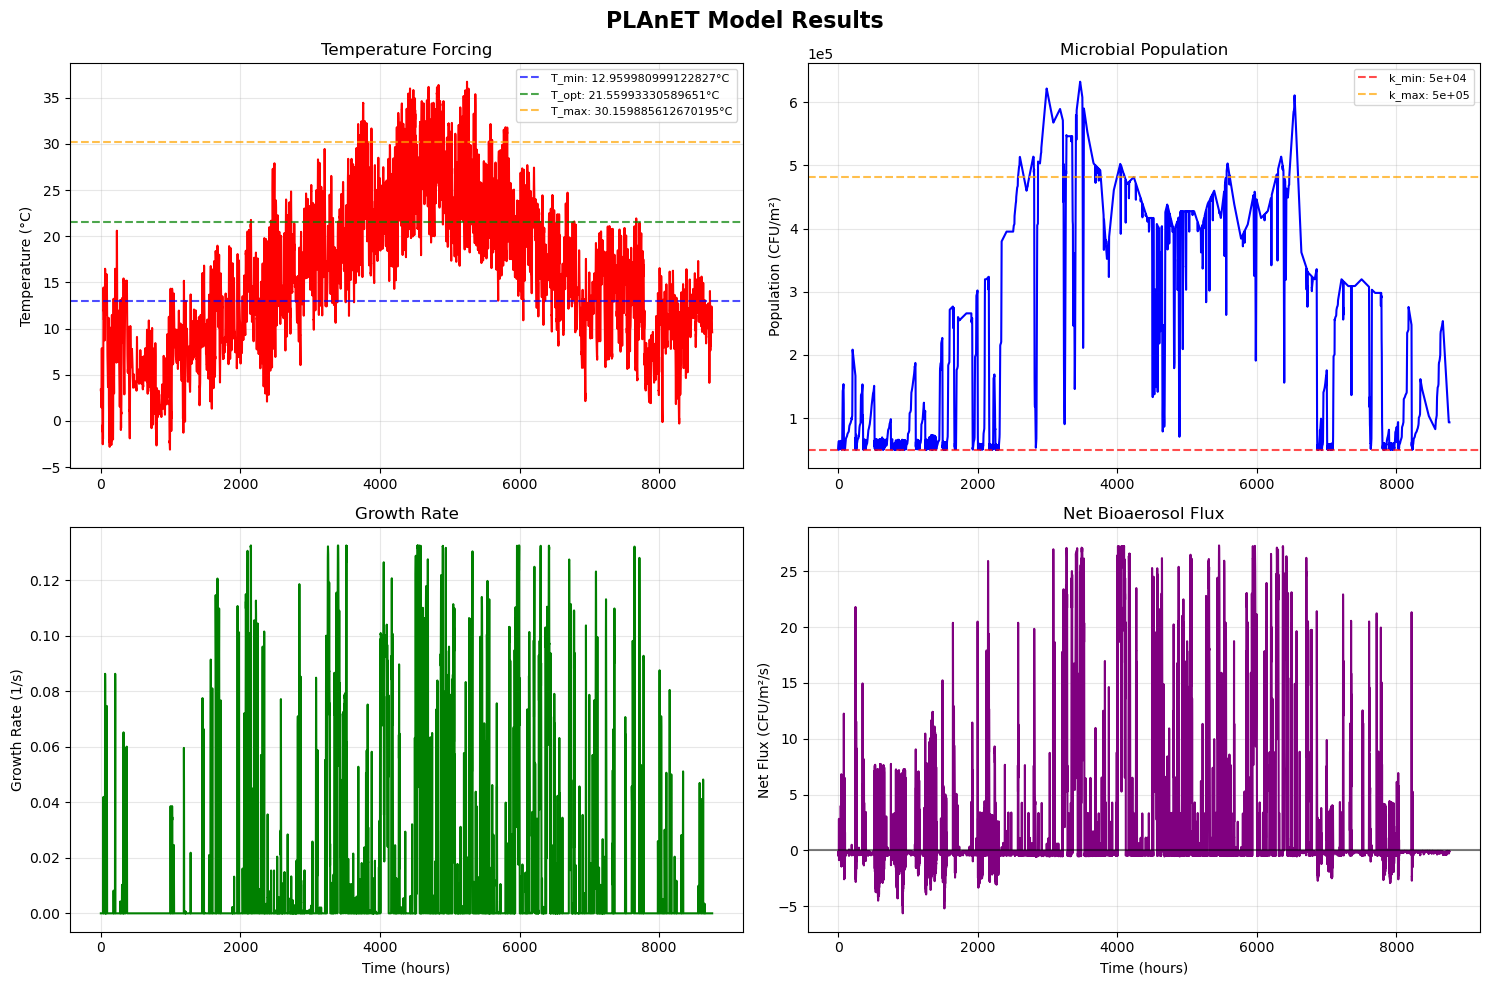


📈 Plots generated successfully!


In [7]:
# Create visualization plots
if 'result' in locals() and 'meteo_data' in locals():
    
    # Create time axis (assuming 30-minute intervals)
    time_hours = np.arange(len(result.population)) * 0.5
    
    # Create subplot figure
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('PLAnET Model Results', fontsize=16, fontweight='bold')
    
    # Plot 1: Temperature forcing
    ax1 = axes[0, 0]
    ax1.plot(time_hours, meteo_data[:, 0], 'red', linewidth=1.5)
    ax1.axhline(params.T_min, color='blue', linestyle='--', alpha=0.7, label=f'T_min: {params.T_min}°C')
    ax1.axhline(params.T_opt, color='green', linestyle='--', alpha=0.7, label=f'T_opt: {params.T_opt}°C')
    ax1.axhline(params.T_max, color='orange', linestyle='--', alpha=0.7, label=f'T_max: {params.T_max}°C')
    ax1.set_title('Temperature Forcing')
    ax1.set_ylabel('Temperature (°C)')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Population dynamics
    ax2 = axes[0, 1]
    ax2.plot(time_hours, result.population, 'blue', linewidth=1.5)
    ax2.axhline(params.k_min, color='red', linestyle='--', alpha=0.7, label=f'k_min: {params.k_min:.0e}')
    ax2.axhline(params.k_max, color='orange', linestyle='--', alpha=0.7, label=f'k_max: {params.k_max:.0e}')
    ax2.set_title('Microbial Population')
    ax2.set_ylabel('Population (CFU/m²)')
    ax2.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Growth rate
    ax3 = axes[1, 0]
    ax3.plot(time_hours, result.growth, 'green', linewidth=1.5)
    ax3.set_title('Growth Rate')
    ax3.set_ylabel('Growth Rate (1/s)')
    ax3.set_xlabel('Time (hours)')
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Net flux
    ax4 = axes[1, 1]
    ax4.plot(time_hours, result.net_flux, 'purple', linewidth=1.5)
    ax4.axhline(0, color='black', linestyle='-', alpha=0.5)
    ax4.set_title('Net Bioaerosol Flux')
    ax4.set_ylabel('Net Flux (CFU/m²/s)')
    ax4.set_xlabel('Time (hours)')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📈 Plots generated successfully!")

In [8]:
# Save results to CSV (optional)
if 'result' in locals() and 'meteo_data' in locals():
    
    # Create results DataFrame
    results_df = pd.DataFrame({
        'time_hours': time_hours,
        'temperature': meteo_data[:, 0],
        'pressure': meteo_data[:, 1],
        'ustar': meteo_data[:, 2],
        'lai': meteo_data[:, 3],
        'population': result.population,
        'growth_rate': result.growth,
        'net_flux': result.net_flux
    })
    
    # Save to CSV
    output_file = 'planet_results.csv'
    results_df.to_csv(output_file, index=False)
    
    print(f"💾 Results saved to: {output_file}")
    print(f"   Columns: {list(results_df.columns)}")
    print(f"   Rows: {len(results_df)}")
    
    # Display first few rows
    print("\nFirst 5 rows of results:")
    print(results_df.head())

💾 Results saved to: planet_results.csv
   Columns: ['time_hours', 'temperature', 'pressure', 'ustar', 'lai', 'population', 'growth_rate', 'net_flux']
   Rows: 17518

First 5 rows of results:
   time_hours  temperature  pressure    ustar   lai    population  \
0         0.0         3.40   98201.0  0.23811  0.35  50362.764809   
1         0.5         3.40   98211.0  0.23240  0.35  50874.472806   
2         1.0         3.33   98220.0  0.22002  0.35  51639.456630   
3         1.5         3.17   98230.0  0.20287  0.35  52500.186663   
4         2.0         3.13   98240.0  0.17906  0.35  53269.094007   

   growth_rate  net_flux  
0          0.0 -0.182657  
1          0.0 -0.284282  
2          0.0 -0.424991  
3          0.0 -0.478183  
4          0.0 -0.427171  


## Comparison with Original MATLAB Net Flux

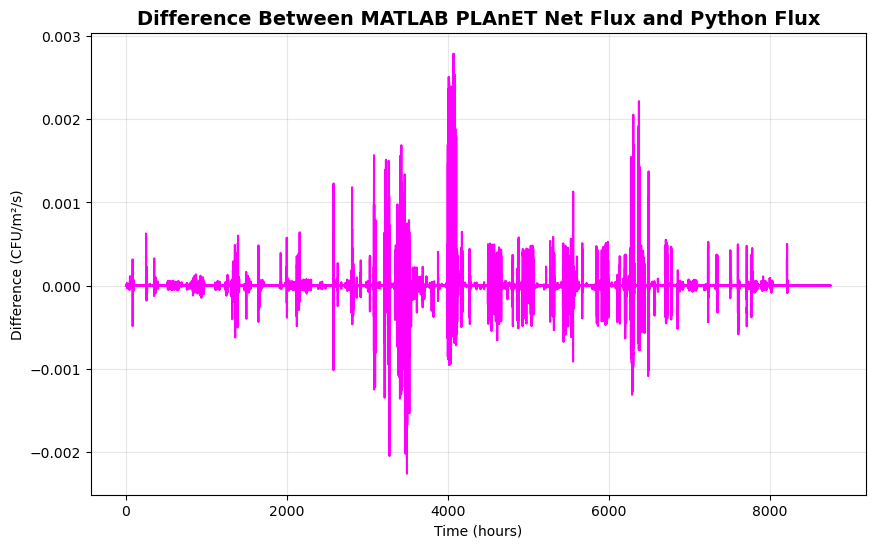


   Net flux  difference range: -0.002 - 0.003 CFU/m²/s
   Min net flux difference: -0.002 CFU/m²/s
   Mean net flux difference: 0.000 CFU/m²/s
   Max net flux difference: 0.003 CFU/m²/s


In [9]:
import pandas as pd
mresults=pd.read_csv('original_matlab_flux_2015.csv',header=None)
dfr=mresults[0]-result.net_flux
fig=plt.figure(figsize=(10,6))
plt.plot(time_hours, dfr, 'magenta', linewidth=1.5)
plt.title('Difference Between MATLAB PLAnET Net Flux and Python Flux', fontsize=14, fontweight='bold')
plt.xlabel('Time (hours)')
plt.ylabel('Difference (CFU/m²/s)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n   Net flux  difference range: {np.min(dfr):.3f} - {np.max(dfr):.3f} CFU/m²/s")
print(f"   Min net flux difference: {np.min(dfr):.3f} CFU/m²/s")
print(f"   Mean net flux difference: {np.mean(dfr):.3f} CFU/m²/s")
print(f"   Max net flux difference: {np.max(dfr):.3f} CFU/m²/s")